In [1]:
!pip install numpy pandas matplotlib scikit-learn --break-system-packages

***Set seed***

In [2]:
import numpy as np
np.random.seed(24521901)

***Import các thư viện cần thiết***


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

***Tạo hàm sinh tập dữ liệu gồm $N$ điểm dữ liệu. Các điểm dữ liệu $(x,y)$ có giá trị input $x$ được phát sinh ngẫu nhiên trong khoảng $(0,1)$ và giá trị target $y = f(x)=sin(1 + x^2) + ε$ với $ε$ tuân theo phân phối chuẩn $N(0,σ=0.03)$.***

In [4]:
def f(x):
    return np.sin(1 + x**2)

def build_dataset(N, std_deviation=0.03):
    X = np.random.rand(N, 1)
    y = f(X) + np.random.randn(N, 1) * std_deviation
    return X, y

def generate_dataset(N, noise_std=0.03):
    features = np.random.rand(N, 1)
    targets = f(features) + np.random.randn(N, 1) * noise_std
    return features, targets

***Với kích thước $N$, tạo một hàm để plot $9$ mô hình polynomial regression có bậc từ $1$ tới $9$ sau khi train $9$ mô hình với từng tập dữ liệu $D1$, $D2$, $D3$. Cũng như bảng thống kê gía trị $E_{in}$ và $E_{out}$ tương ứng với $9$ mô hình với tập dữ liệu $D1$.***

In [5]:
def plot_polynomial_regression(N, max_degree = 9):
    dt_train = [generate_dataset(N) for _ in range(3)]
    dt_test = [generate_dataset(N) for _ in range(3)]

    results = []
    colors = ['red', 'green', 'blue']
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    fig.suptitle(f'Plot Polynomial Regression (N={N})', fontsize=14)

    for i, (train, test) in enumerate(zip(dt_train, dt_test)):
        X_train, y_train = train
        X_test, y_test = test

        for deg_index_zero in range(max_degree):
            deg = deg_index_zero + 1

            poly = PolynomialFeatures(deg)
            X_train_poly = poly.fit_transform(X_train)
            X_test_poly = poly.transform(X_test)

            model = LinearRegression()
            model.fit(X_train_poly, y_train)

            y_train_pred = model.predict(X_train_poly)
            y_test_pred = model.predict(X_test_poly)

            err_in = mean_squared_error(y_train, y_train_pred)
            err_out = mean_squared_error(y_test, y_test_pred)

            if i == 0:
                results.append((deg, err_in, err_out))

            X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
            y_plot = model.predict(poly.transform(X_plot))

            ax = axes[(deg - 1) // 3, (deg - 1) % 3]
            ax.plot(X_plot, y_plot, color=colors[i], label=f'Dataset {i + 1}')
            ax.set_title(f'Degree {deg}', fontsize=10)
            ax.set_ylim(0.7, 1.1)
            ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    df = pd.DataFrame(results, columns=['Degree', 'E_in', 'E_out'])
    return df

## Với kích thước tập dữ liệu $N=10$

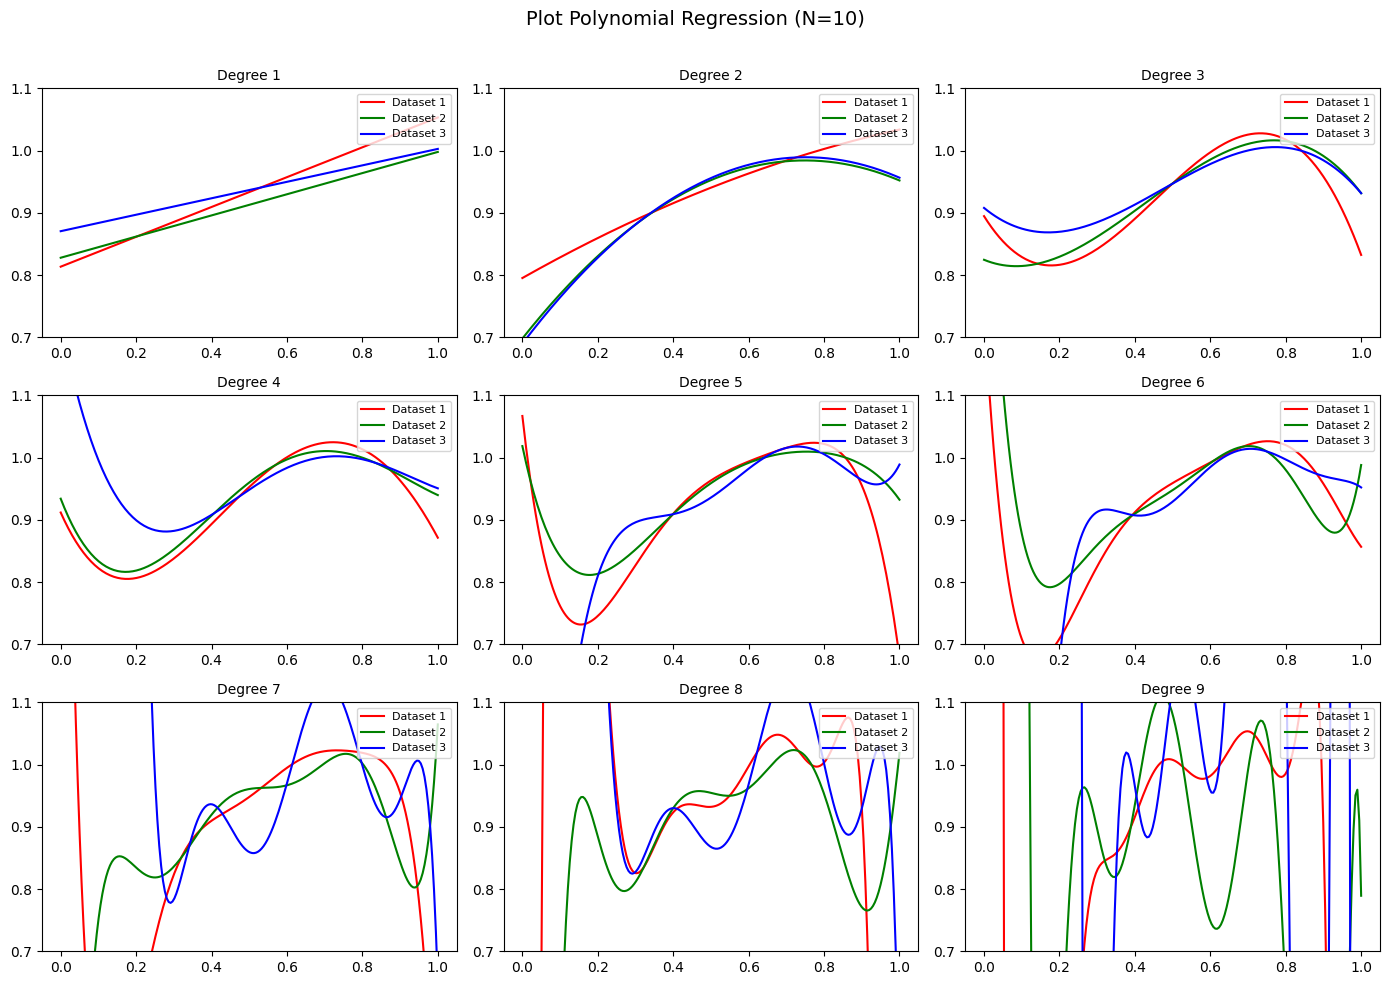

,Degree,E_in,E_out
0,1,1.825979e-03,0.002921
1,2,1.782667e-03,0.002287
2,3,3.975582e-04,0.002400
3,4,3.855796e-04,0.002130
4,5,3.117947e-04,0.005829
5,6,3.036042e-04,0.003396
6,7,2.934847e-04,0.017807
7,8,9.918997e-05,1.372743
8,9,1.264305e-20,13.364349


In [6]:
plot_polynomial_regression(N = 10)

## Với kích thước tập dữ liệu $N=100$

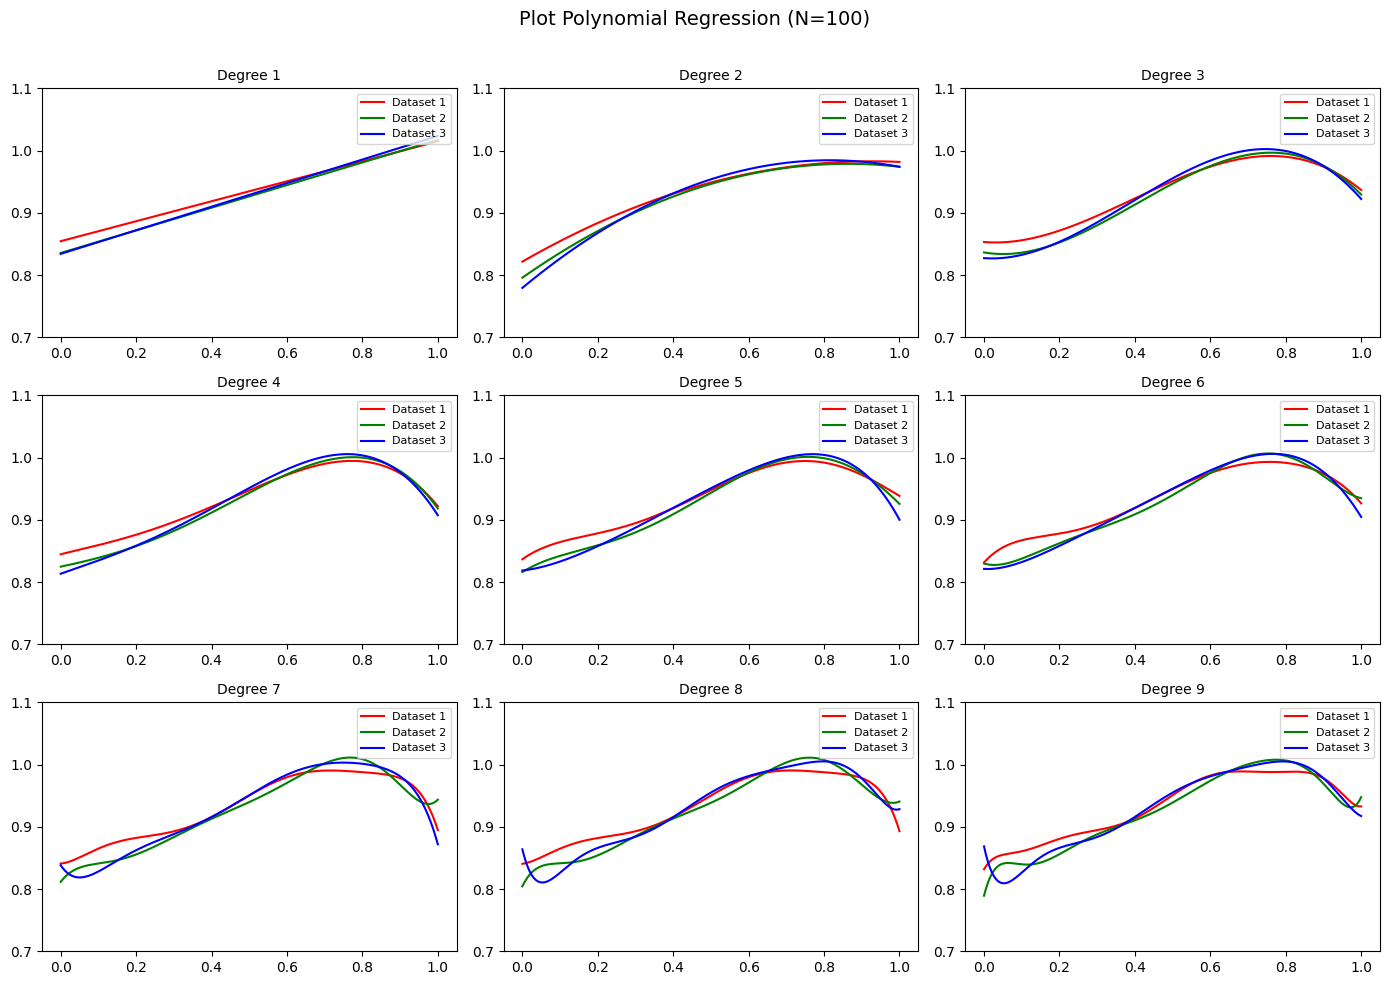

,Degree,E_in,E_out
0,1,0.001084,0.002111
1,2,0.000904,0.001438
2,3,0.000740,0.000934
3,4,0.000730,0.000928
4,5,0.000723,0.000993
5,6,0.000720,0.000962
6,7,0.000711,0.000965
7,8,0.000711,0.000964
8,9,0.000704,0.000975


In [7]:
plot_polynomial_regression(N = 100)

## Với kích thước tập dữ liệu $N=1000$

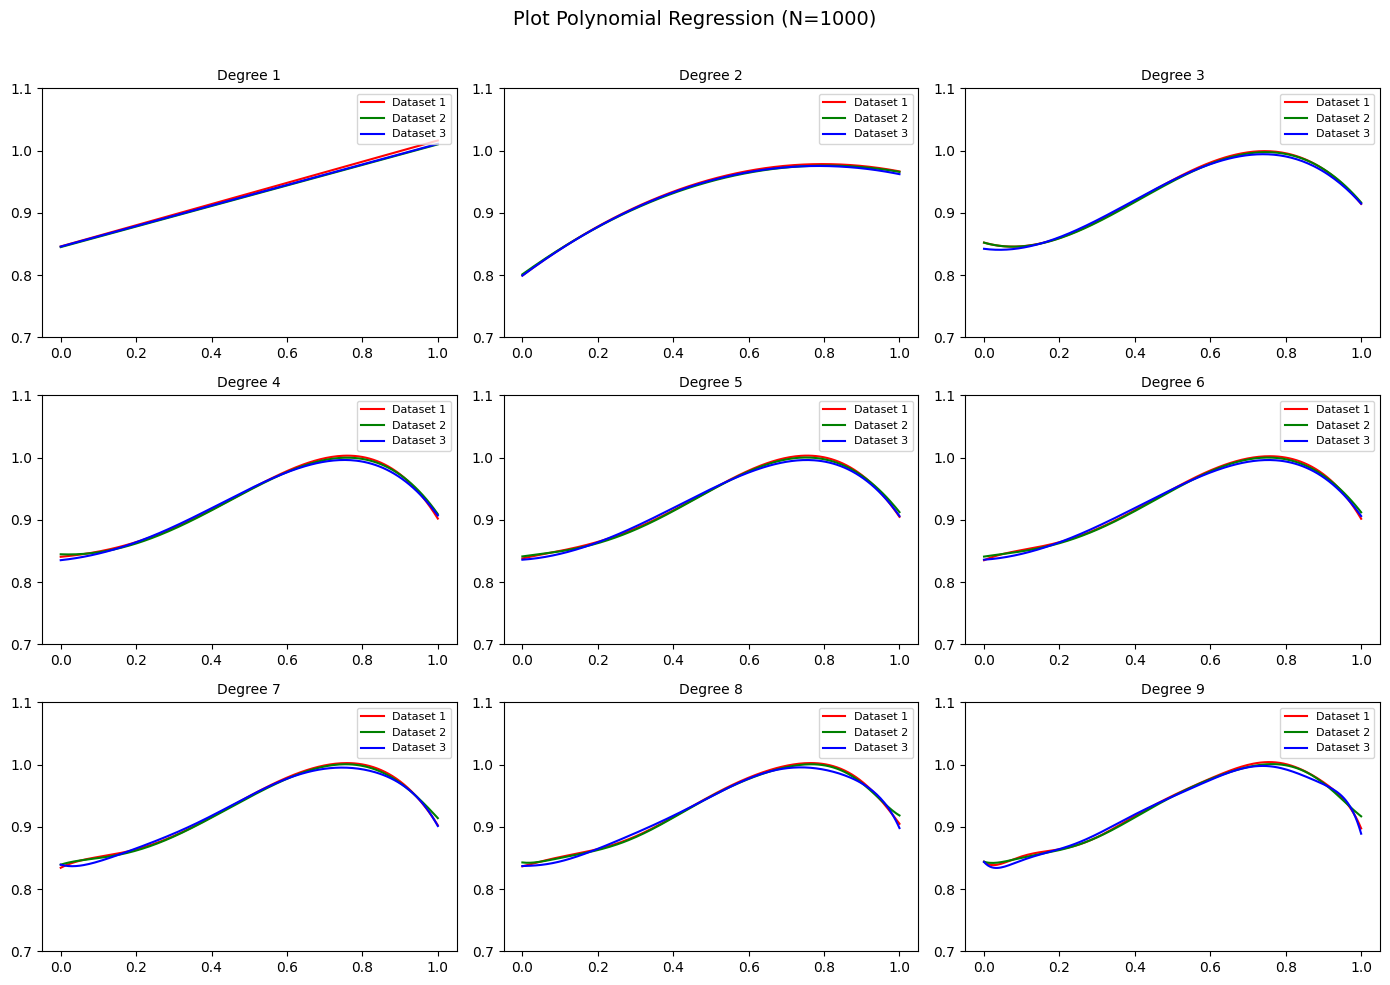

,Degree,E_in,E_out
0,1,0.001760,0.001627
1,2,0.001327,0.001214
2,3,0.000948,0.000836
3,4,0.000932,0.000825
4,5,0.000931,0.000825
5,6,0.000930,0.000826
6,7,0.000930,0.000826
7,8,0.000930,0.000824
8,9,0.000927,0.000826


In [8]:
plot_polynomial_regression(N = 1000)

## Nhận xét

Từ việc quan sát bảng thống kê $E_{in}$, $E_{out}$, ta có một số kết luận sau:
- Với cùng kích thước, khi ta tăng bậc của đa thức lên, thì $E_{in}$ càng giảm. Điều đó cho thấy khi **tăng độ phức tạp của mô hình thì bias sẽ giảm** do mô hình sẽ càng fitting data hơn.

- Khi **tăng độ phức tạp của mô hình thì variance tới một mức độ nào đó sẽ tăng**. Điều này xảy ra vì khi tăng độ phức tạp của mô hình thì mô hình sẽ bị tình trạng học quá kĩ tập train dẫn tới không còn đạt kết qủa tốt trên tập test nữa. Dễ thấy điều này tại $N=10$, bậc của mô hình tới một mức nào đó khi tăng lên, $E_{out}$ cũng tăng lên.

- **bias không ảnh hưởng khi tăng kích thước tập train**. Bởi vì bias phụ thuộc vào cấu trúc của mô hình chứ không phụ thuộc vào kích thước của tập dữ liệu. Ta có thể thấy điều đó tại $N=10, N=100, N=1000$, bias vẫn giảm khi tăng độ phức tạp của mô hình (Tức nó vẫn có cùng tính chất chứ không thể thay đổi khi tăng kích thước dữ liệu).

- Khi **tăng kích thước tập train, variance sẽ giảm**, vì khi kích thước tập dữ liệu chưa đủ lớn, mô hình sẽ bị overfit (Có thể thấy điều đó tại bậc $9$ của $N=10$, mô hình cố gắng học thuộc từng điểm dữ liệu hay vì có học quy luật của hàm đích). Nhưng khi mô hình lớn hơn, mô hình sẽ đỡ bị tình trạng overfit hơn. Ta có thể thấy khi $N$ tăng dần thì $E_{out}$ có xu hướng giảm.
